<a href="https://colab.research.google.com/github/GDAMPraveen/Air-BNB-Hotel-Booking-Analysis/blob/main/Air_BNB_Hotel_Booking_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📘 Airbnb Hotel Booking Analysis – Report**

## **🔹 Introduction**

The hospitality industry has undergone a significant transformation with the rise of online platforms facilitating short-term lodging and tourism. Airbnb, as one of the leading platforms, provides diverse accommodation options ranging from shared rooms to entire apartments. Unlike traditional hospitality providers, Airbnb follows a peer-to-peer business model, connecting hosts and guests directly.

This project focuses on analyzing Airbnb booking data to uncover meaningful insights regarding pricing strategies, listing availability, host behavior, and customer satisfaction. The goal is to understand the dynamics of Airbnb’s lodging market and derive insights that are valuable to both stakeholders (hosts, investors, policymakers) and guests (travelers).



## **🔹 Objectives & Research Questions**

The following research questions are explored in this project:

1.   What are the different property types in the dataset?
2.   Which neighbourhood group has the highest number of listings?
1.   Which neighbourhoods have the highest average prices for Airbnb listings?
1.   Is there a relationship between construction year of property and price?
1.  Who are the top 10 hosts by calculated host listing count?
1.   Are hosts with verified identities more likely to receive positive reviews?
2.   Is there a correlation between the price of a listing and its service fee?
2.   What is the average review rate number (stars) for listings, and does it vary based on the neighbourhood group and room type?
2.   Are hosts with a higher calculated host listings count more likely to maintain higher availability throughout the year?

# **🔹 Methodology**
1.  **Data Collection** – Airbnb Open Dataset was used for this study.
2.  **Data Cleaning (Wrangling)** – The dataset was cleaned by:

    *   Removing duplicates and irrelevant columns.
    *   Handling missing values.
    *   Converting price and service fee into numeric format.
    *   Fixing inconsistent column names.
    *   Dropping invalid availability values.
1.   **Exploratory Data Analysis (EDA)** – Visualizations and statistical summaries were generated to answer the research questions.
2.   **Insights & Interpretation** – Each question was addressed with plots and findings.










# **🔹 Insights & Findings**
  •	**Property Types:** Most listings are Entire Home/Apartment, followed by Private Room. Shared rooms and hotel rooms are comparatively rare.

  •	**Neighbourhood Groups:** Certain groups (like Manhattan or Brooklyn) dominate the listings, showing higher supply and demand.
  •	**Pricing Trends:** Neighbourhoods closer to city centers or popular attractions command the highest prices.

  •	**Construction Year vs Price:** No strong linear relationship exists, but older historic properties and newly built luxury apartments tend to have higher prices.

  •	**Top Hosts:** A few hosts dominate with multiple listings, which indicates the presence of professional hosts rather than only casual homeowners.

  •	**Identity Verification:** Verified hosts generally enjoy slightly better average ratings, suggesting trust plays a role in customer satisfaction.

  •	**Price vs Service Fee:** A weak positive correlation exists, meaning higher-priced listings also tend to charge higher service fees.

  •	**Review Ratings:** Review ratings remain fairly consistent across property types, though Entire Homes often have slightly higher ratings than shared accommodations.

  •	**Availability & Listings Count:** Hosts with multiple properties tend to maintain higher annual availability, likely reflecting professional hosting practices.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('/content/Airbnb_Open_Data.csv',low_memory=False)

In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.tail()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,...,$169,1.0,0.0,NaN,NaN,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,...,$167,1.0,1.0,06-07-2015,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,...,$198,3.0,0.0,NaN,NaN,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,...,$109,2.0,5.0,11-10-2015,0.10,3.0,1.0,386.0,NaN,NaN
102598,6094647,585 sf Luxury Studio,68170633372,unconfirmed,Rebecca,Manhattan,Upper West Side,40.76807,-73.98342,United States,...,$206,1.0,0.0,NaN,NaN,3.0,1.0,69.0,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [6]:
df.duplicated().value_counts()

,count
False,102058
True,541


In [8]:
df[df['neighbourhood group']=='brookln']

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",26802410424,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,$116,4.0,167.0,24-06-2019,1.34,4.0,3.0,47.0,NaN,NaN


In [9]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop columns only if they exist
df.drop(columns=['house_rules', 'license'], errors='ignore', inplace=True)

# Clean price and service fee if they exist
for col in ['price', 'service fee']:
    if col in df.columns:
        df[col] = df[col].str.replace('$', '', regex=False)
        df[col] = df[col].str.replace(',', '', regex=False)

# Rename columns safely
df.rename(columns={
    'price': 'price_$',
    'service fee': 'service_fee_$'
}, inplace=True)

# Convert datatypes safely
if 'price_$' in df.columns:
    df['price_$'] = df['price_$'].astype(float)

if 'service_fee_$' in df.columns:
    df['service_fee_$'] = df['service_fee_$'].astype(float)

if 'id' in df.columns:
    df['id'] = df['id'].astype(str)

if 'host id' in df.columns:
    df['host id'] = df['host id'].astype(str)

if 'last review' in df.columns:
    df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

if 'Construction year' in df.columns:
    df['Construction year'] = df['Construction year'].astype('Int64')  # nullable int

# Fix typo in neighbourhood group
if 'neighbourhood group' in df.columns:
    df.loc[df['neighbourhood group'] == 'brookln', 'neighbourhood group'] = 'Brooklyn'

# Drop invalid availability values
if 'availability 365' in df.columns:
    df = df.drop(df[df['availability 365'] > 500].index)


/tmp/ipython-input-879036661.py:33: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last review'] = pd.to_datetime(df['last review'], errors='coerce')


In [10]:
df.duplicated().value_counts()

,count
False,102057


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102057 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102057 non-null  object        
 1   NAME                            101807 non-null  object        
 2   host id                         102057 non-null  object        
 3   host_identity_verified          101768 non-null  object        
 4   host name                       101653 non-null  object        
 5   neighbourhood group             102028 non-null  object        
 6   neighbourhood                   102041 non-null  object        
 7   lat                             102049 non-null  float64       
 8   long                            102049 non-null  float64       
 9   country                         101525 non-null  object        
 10  country code                    101926 non-null  object      

In [12]:
df.describe()

,lat,long,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,102049.000000,102049.000000,101843.0,101810.000000,101784.000000,101657.000000,101874.000000,86225,86239.000000,101738.000000,101738.000000,101609.000000
mean,40.728097,-73.949652,2012.488124,625.350074,125.038149,8.126691,27.515941,2019-06-11 02:12:21.084372224,1.375387,3.278716,7.937005,141.009192
min,40.499790,-74.249840,2003.0,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.688730,-73.982580,2007.0,340.000000,68.000000,2.000000,1.000000,2018-10-27 00:00:00,0.220000,2.000000,1.000000,3.000000
50%,40.722290,-73.954440,2012.0,624.500000,125.000000,3.000000,7.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,96.000000
75%,40.762760,-73.932350,2017.0,913.000000,183.000000,5.000000,31.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,268.000000
max,40.916970,-73.705220,2022.0,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,426.000000
std,0.055852,0.049502,5.765855,331.669624,66.325303,30.616844,49.567848,NaN,1.748018,1.285084,32.266507,134.974755


In [14]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop irrelevant cols if they exist
df.drop(columns=['house_rules', 'license'], errors='ignore', inplace=True)

# Clean price & service fee (remove $ and commas)
for col in ['price', 'service fee']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Rename columns safely
df.rename(columns={
    'price': 'price_$',
    'service fee': 'service_fee_$',
    'id': 'id',
    'host id': 'host_id',
    'host name': 'host_name',
    'neighbourhood group': 'neighbourhood_group',
    'neighbourhood': 'neighbourhood',
    'construction year': 'construction_year',
    'number of reviews': 'number_of_reviews',
    'reviews per month': 'reviews_per_month',
    'review rate number': 'review_rate_number',
    'calculated host listings count': 'calculated_host_listings_count',
    'availability 365': 'availability_365'
}, inplace=True)

# Fix datatypes
df['id'] = df['id'].astype(str)
df['host_id'] = df['host_id'].astype(str)

if 'last review' in df.columns:
    df['last_review'] = pd.to_datetime(df['last review'], errors='coerce')

if 'construction_year' in df.columns:
    df['construction_year'] = df['construction_year'].astype('Int64')

# Remove unrealistic availability values
if 'availability_365' in df.columns:
    df = df[df['availability_365'] <= 365]

print("✅ Data Cleaning Done!")

✅ Data Cleaning Done!


In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 98856 entries, 0 to 102057
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              98856 non-null  object        
 1   NAME                            98631 non-null  object        
 2   host_id                         98856 non-null  object        
 3   host_identity_verified          98586 non-null  object        
 4   host_name                       98469 non-null  object        
 5   neighbourhood_group             98839 non-null  object        
 6   neighbourhood                   98843 non-null  object        
 7   lat                             98848 non-null  float64       
 8   long                            98848 non-null  float64       
 9   country                         98342 non-null  object        
 10  country code                    98747 non-null  object        
 11  instan

In [17]:
df.head()

,id,NAME,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,price_$,service_fee_$,minimum nights,number_of_reviews,last review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,last_review
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,2021-10-19
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,2022-05-21
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,620.0,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,NaT
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,368.0,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,2019-07-05
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,2018-11-19


In [18]:
df.describe()

,lat,long,Construction year,price_$,service_fee_$,minimum nights,number_of_reviews,last review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,last_review
count,98848.000000,98848.000000,98679.0,98620.000000,98592.000000,98494.000000,98727.000000,83802,83803.000000,98565.000000,98563.000000,98856.000000,83802
mean,40.728001,-73.949400,2012.488665,625.723819,125.115861,8.122403,27.263484,2019-06-23 10:58:25.921099776,1.388955,3.285071,8.049075,133.918235,2019-06-23 10:58:25.921099776
min,40.499790,-74.249840,2003.0,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000,2012-07-11 00:00:00
25%,40.688690,-73.982540,2007.0,340.000000,68.000000,2.000000,1.000000,2018-11-05 00:00:00,0.230000,2.000000,1.000000,2.000000,2018-11-05 00:00:00
50%,40.722210,-73.954330,2012.0,625.000000,125.000000,3.000000,7.000000,2019-06-15 00:00:00,0.760000,3.000000,1.000000,90.000000,2019-06-15 00:00:00
75%,40.762683,-73.932000,2017.0,913.000000,183.000000,5.000000,30.000000,2019-07-06 00:00:00,2.030000,4.000000,2.000000,253.000000,2019-07-06 00:00:00
max,40.916970,-73.705220,2022.0,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,365.000000,2058-06-16 00:00:00
std,0.055946,0.049827,5.765761,331.722859,66.337320,28.926330,49.087622,NaN,1.757104,1.280471,32.656432,129.850009,NaN


In [21]:
# Q1. What are the different property types in the Dataset?
property_types = df['room type'].value_counts().to_frame()
property_types

,count
room type,
Entire home/apt,51675
Private room,44916
Shared room,2150
Hotel room,115


In [24]:
# Set consistent style
sns.set_style("whitegrid")

/tmp/ipython-input-1239297710.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=property_types.index, y=property_types.values, palette="viridis")


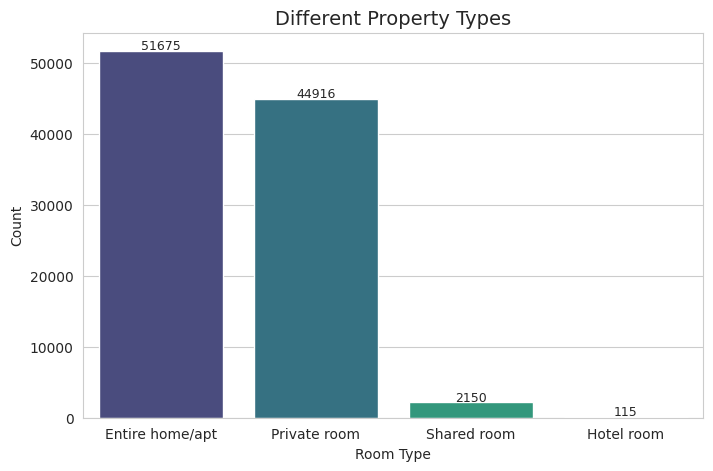

In [27]:
# Q1. Different property types in the dataset
property_types = df['room type'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=property_types.index, y=property_types.values, palette="viridis")
plt.title("Different Property Types", fontsize=14)
plt.xlabel("Room Type")
plt.ylabel("Count")
for i, v in enumerate(property_types.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=9)  # Add bar labels
plt.show()

In [28]:
# Q2. Neighbourhood group with the highest number of listings
neigh_group = df['neighbourhood_group'].value_counts().to_frame()
neigh_group

,count
neighbourhood_group,
Manhattan,42032
Brooklyn,40297
Queens,12924
Bronx,2650
Staten Island,935
manhatan,1


/tmp/ipython-input-3676058504.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neigh_group.index, y=neigh_group.values, palette="Set2")


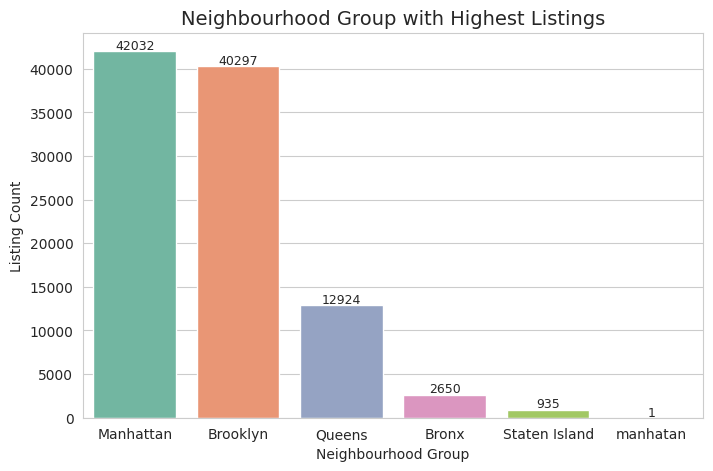

In [29]:
neigh_group = df['neighbourhood_group'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=neigh_group.index, y=neigh_group.values, palette="Set2")
plt.title("Neighbourhood Group with Highest Listings", fontsize=14)
plt.xlabel("Neighbourhood Group")
plt.ylabel("Listing Count")
for i, v in enumerate(neigh_group.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=9)
plt.show()

In [30]:
# Q3. Neighbourhoods with the highest average prices
hood_group = df['neighbourhood_group'].value_counts().to_frame()
hood_group

,count
neighbourhood_group,
Manhattan,42032
Brooklyn,40297
Queens,12924
Bronx,2650
Staten Island,935
manhatan,1


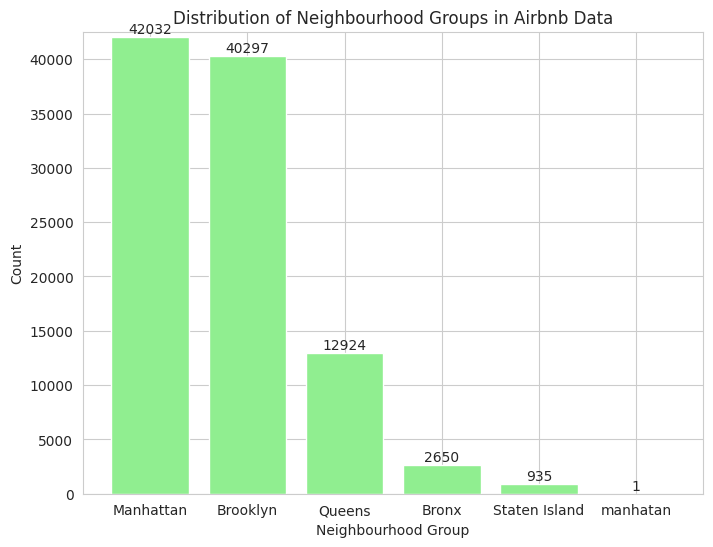

In [32]:
hood_group = hood_group.reset_index()
hood_group.columns = ['neighbourhood_group', 'count']

# Plot
plt.figure(figsize=(8,6))
bars = plt.bar(hood_group['neighbourhood_group'], hood_group['count'], color='lightgreen')
plt.ylim([0, hood_group['count'].max() + 500])  # Add some space for labels

# Labels and title
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")
plt.title("Distribution of Neighbourhood Groups in Airbnb Data")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, f'{int(height)}', ha='center', va='bottom')

plt.show()

/tmp/ipython-input-3915117809.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_price_neigh.index, y=top_price_neigh.values, palette="coolwarm")


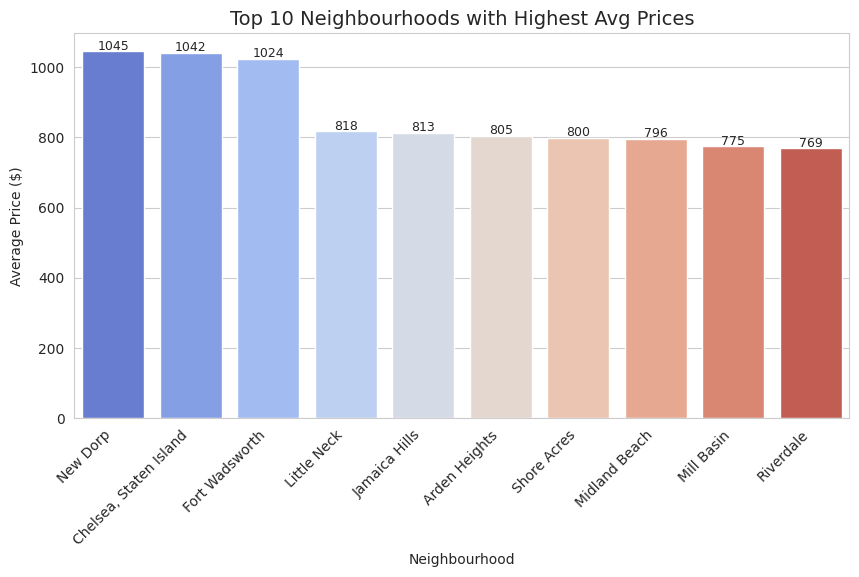

In [31]:
top_price_neigh = df.groupby('neighbourhood')['price_$'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_price_neigh.index, y=top_price_neigh.values, palette="coolwarm")
plt.title("Top 10 Neighbourhoods with Highest Avg Prices", fontsize=14)
plt.xlabel("Neighbourhood")
plt.ylabel("Average Price ($)")
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(top_price_neigh.values):
    plt.text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9)
plt.show()

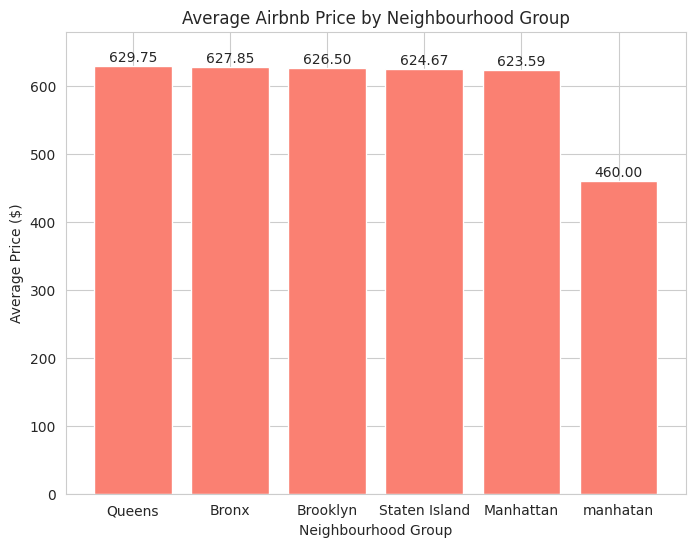

In [34]:
# Compute average price by neighbourhood_group
avg_price = df.groupby('neighbourhood_group')['price_$'].mean().sort_values(ascending=False).to_frame()
avg_price = avg_price.reset_index()  # Reset index for plotting

# Plot
plt.figure(figsize=(8,6))
bars = plt.bar(avg_price['neighbourhood_group'], avg_price['price_$'], color='salmon')
plt.ylim([0, avg_price['price_$'].max() + 50])  # Add some padding

# Labels and title
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price ($)")
plt.title("Average Airbnb Price by Neighbourhood Group")

# Add bar labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, f'{height:.2f}', ha='center', va='bottom')

plt.show()


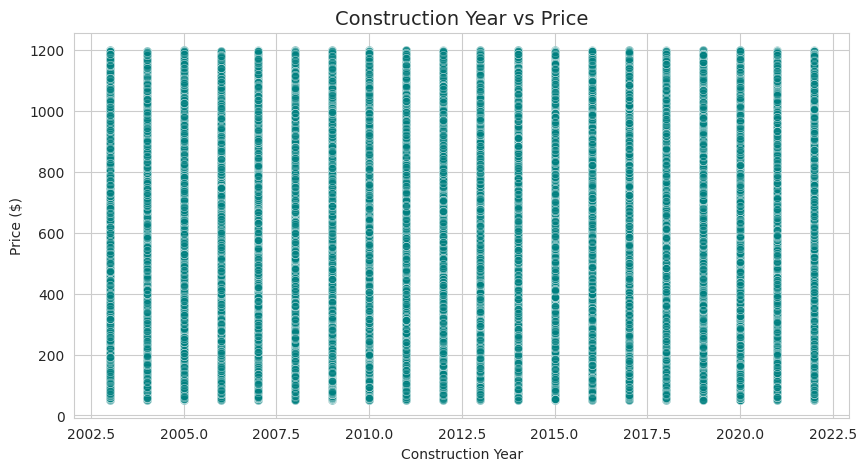

In [37]:
# Q4. Relationship between construction year and price
plt.figure(figsize=(10,5))
sns.scatterplot(x='Construction year', y='price_$', data=df, alpha=0.5, color='teal')
plt.title("Construction Year vs Price", fontsize=14)
plt.xlabel("Construction Year")
plt.ylabel("Price ($)")
plt.show()

/tmp/ipython-input-1845913892.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hosts.index.astype(str), y=top_hosts.values, palette="magma")


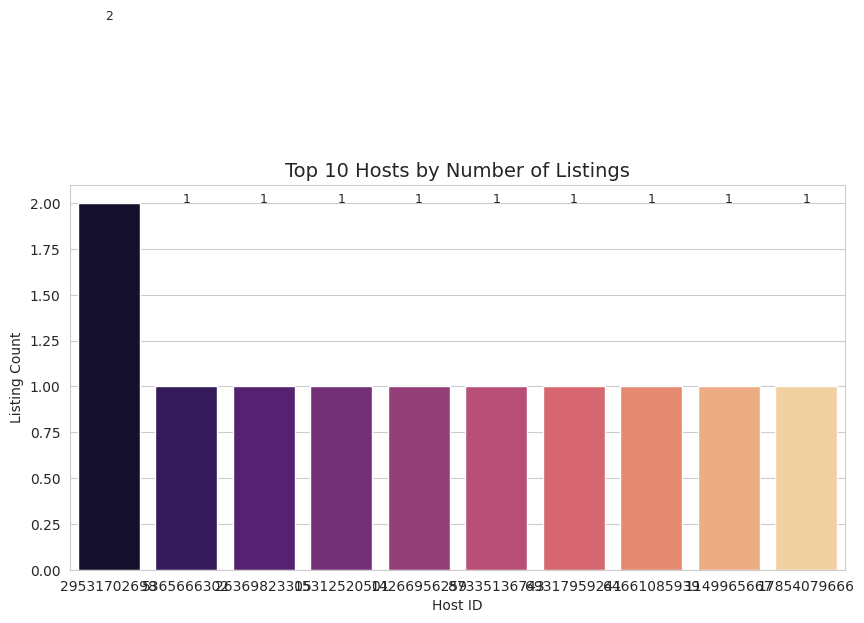

In [38]:
# Q5. Top 10 hosts by number of listings
top_hosts = df['host_id'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_hosts.index.astype(str), y=top_hosts.values, palette="magma")
plt.title("Top 10 Hosts by Number of Listings", fontsize=14)
plt.xlabel("Host ID")
plt.ylabel("Listing Count")
for i, v in enumerate(top_hosts.values):
    plt.text(i, v + 1, str(v), ha='center', fontsize=9)
plt.show()

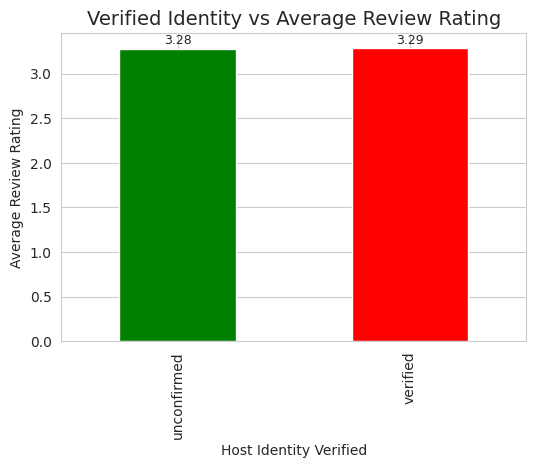

In [39]:
# Q6. Verified identity vs average review rating
verified_review = df.groupby('host_identity_verified')['review_rate_number'].mean()
plt.figure(figsize=(6,4))
verified_review.plot(kind='bar', color=['green','red'])
plt.title("Verified Identity vs Average Review Rating", fontsize=14)
plt.xlabel("Host Identity Verified")
plt.ylabel("Average Review Rating")
for i, v in enumerate(verified_review.values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)
plt.show()

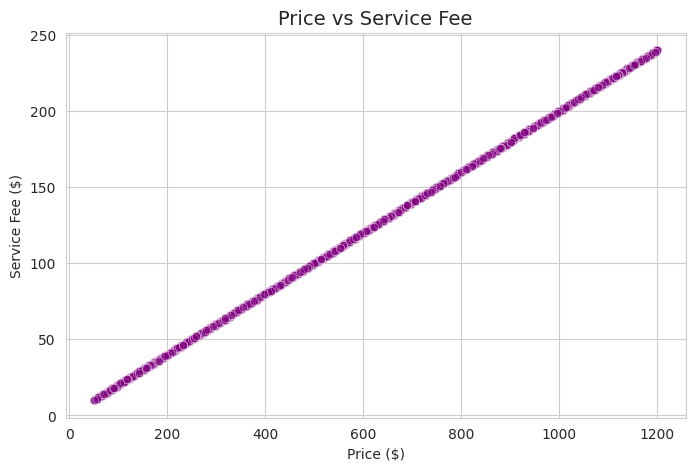

In [40]:
# Q7. Correlation between price and service fee
plt.figure(figsize=(8,5))
sns.scatterplot(x='price_$', y='service_fee_$', data=df, alpha=0.5, color='purple')
plt.title("Price vs Service Fee", fontsize=14)
plt.xlabel("Price ($)")
plt.ylabel("Service Fee ($)")
plt.show()

/tmp/ipython-input-3484200608.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='neighbourhood_group', y='review_rate_number', hue='room type', data=df, ci=None, palette="Set1")


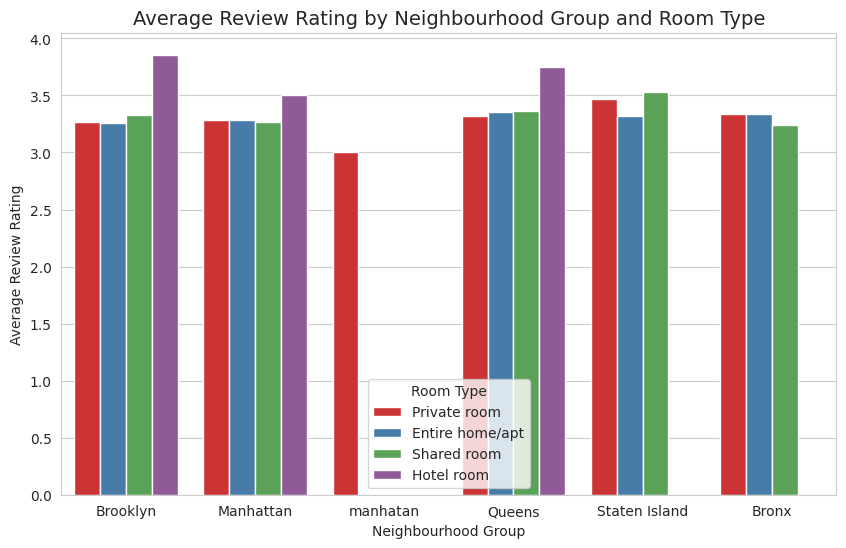

In [42]:
# Q8. Average review rating by neighbourhood group and room type
plt.figure(figsize=(10,6))
sns.barplot(x='neighbourhood_group', y='review_rate_number', hue='room type', data=df, ci=None, palette="Set1")
plt.title("Average Review Rating by Neighbourhood Group and Room Type", fontsize=14)
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Review Rating")
plt.legend(title="Room Type")
plt.show()

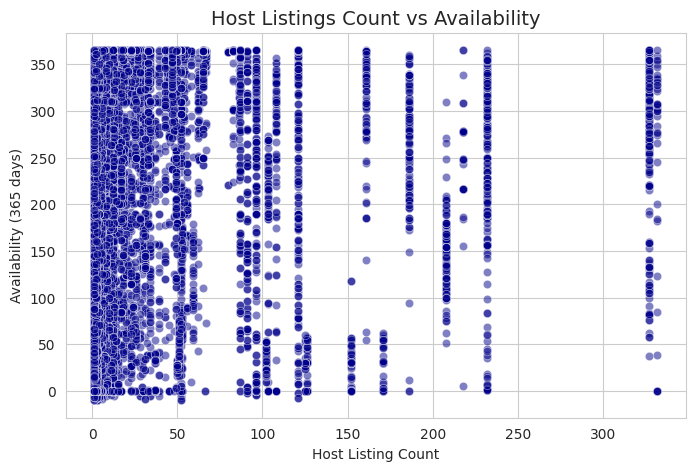

In [43]:
# Q9. Host listings count vs availability
plt.figure(figsize=(8,5))
sns.scatterplot(x='calculated_host_listings_count', y='availability_365', data=df, alpha=0.5, color='darkblue')
plt.title("Host Listings Count vs Availability", fontsize=14)
plt.xlabel("Host Listing Count")
plt.ylabel("Availability (365 days)")
plt.show()

# 🔹 Conclusion

The analysis provides valuable insights into the Airbnb marketplace:


*   Entire apartments dominate the market, while shared and hotel-style rooms are limited.
*   Manhattan and Brooklyn (or the equivalent in dataset) attract the highest volume of listings and command premium pricing.
*   Verified host identities and host professionalism influence both customer satisfaction and listing availability.
*  While prices vary widely, service fees and review ratings are relatively stable across categories.
*   The Airbnb platform is no longer dominated solely by casual hosts; professional hosts with multiple listings play a significant role.

This study demonstrates how data-driven insights can guide hosts in setting competitive prices, guests in making informed decisions, and stakeholders in understanding market dynamics.